#### CONTENTS OF THIS NOTEBOOK
##### 1. Importing the final processed (transformed and scaled) dataset and rearranging the columns properly.
##### 2. Training HDBSCAN and GMM models, finalizing GMM model and finding the clusters.
##### 3. Cluster profiling (studying the clusters to find the customer behavior in each cluster).
##### 4. Suggesting targeted marketing actions to each cluster based on their behavior to increase the revenue and customer retention.
##### 5. Estimating business impact of the targeted marketing strategies.
##### 6. Visualization of the business impact
##### 7. Key business takeaways and recommendations
##### 8. Assumptions and limitations

In [3]:
# Importing the required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from hdbscan import HDBSCAN
from sklearn.mixture import GaussianMixture

In [4]:
# Importing the processed dataset and final_features.csv

final_df = pd.read_csv("../data/processed/final_features.csv")
processed_df = pd.read_csv("../data/processed/processed_features.csv")
processed_df.head()

,avg_items_per_order,active_months,monetary_per_active_month,frequency_per_active_month,inter_purchase_gap_mean,inter_purchase_gap_std,user_id
0,-0.688255,-0.36243,-0.930419,0.0,-0.37184,-0.113976,1.0
1,1.382901,-0.36243,-0.471491,0.0,-0.37184,-0.113976,7.0
2,-0.688255,-0.36243,-0.057412,0.0,-0.37184,-0.113976,12.0
3,-0.688255,-0.36243,-0.120142,0.0,-0.37184,-0.113976,13.0
4,-0.688255,-0.36243,-0.125443,0.0,-0.37184,-0.113976,15.0


In [5]:
# Rearranging the columns to bring the user_id to the first position:

cols = list(processed_df.columns)
new_cols = ["user_id"] + [col for col in cols if col != "user_id"]
processed_df = processed_df[new_cols]
processed_df.head()

,user_id,avg_items_per_order,active_months,monetary_per_active_month,frequency_per_active_month,inter_purchase_gap_mean,inter_purchase_gap_std
0,1.0,-0.688255,-0.36243,-0.930419,0.0,-0.37184,-0.113976
1,7.0,1.382901,-0.36243,-0.471491,0.0,-0.37184,-0.113976
2,12.0,-0.688255,-0.36243,-0.057412,0.0,-0.37184,-0.113976
3,13.0,-0.688255,-0.36243,-0.120142,0.0,-0.37184,-0.113976
4,15.0,-0.688255,-0.36243,-0.125443,0.0,-0.37184,-0.113976


In [6]:
# Converting the dtype of user_id to int:

processed_df["user_id"] = processed_df["user_id"].astype(int)
processed_df.head()

,user_id,avg_items_per_order,active_months,monetary_per_active_month,frequency_per_active_month,inter_purchase_gap_mean,inter_purchase_gap_std
0,1,-0.688255,-0.36243,-0.930419,0.0,-0.37184,-0.113976
1,7,1.382901,-0.36243,-0.471491,0.0,-0.37184,-0.113976
2,12,-0.688255,-0.36243,-0.057412,0.0,-0.37184,-0.113976
3,13,-0.688255,-0.36243,-0.120142,0.0,-0.37184,-0.113976
4,15,-0.688255,-0.36243,-0.125443,0.0,-0.37184,-0.113976


In [7]:
# Separating the user_id from the processed_df before implementing the model

X_processed = processed_df.drop("user_id", axis = 1)
X_processed.head()

,avg_items_per_order,active_months,monetary_per_active_month,frequency_per_active_month,inter_purchase_gap_mean,inter_purchase_gap_std
0,-0.688255,-0.36243,-0.930419,0.0,-0.37184,-0.113976
1,1.382901,-0.36243,-0.471491,0.0,-0.37184,-0.113976
2,-0.688255,-0.36243,-0.057412,0.0,-0.37184,-0.113976
3,-0.688255,-0.36243,-0.120142,0.0,-0.37184,-0.113976
4,-0.688255,-0.36243,-0.125443,0.0,-0.37184,-0.113976


##### Training HDBSCAN model

##### HDBSCAN model works well with data having outliers and skewness, and they do not assume any specific-shaped clusters, so trying HDBSCAN model:

In [8]:
# Converting the dataframe X_processed into numpy array, because HDBSCAN works well with numpy arrays.
X = X_processed.values

# Creating clusters
clusterer = HDBSCAN(min_cluster_size = 500, min_samples = 150, metric='euclidean', cluster_selection_method='eom')
labels = clusterer.fit_predict(X)
labels

array([ 8,  3, 11, ...,  3, -1, 10], shape=(26123,))

In [9]:
# Finding the number of clusters

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print("Number of clusters:", n_clusters)

Number of clusters: 13


In [ ]:
# Calculating the noise ratio:

noise_ratio = np.sum(labels == -1) / len(labels)
print("Noise ratio:", noise_ratio)

Noise ratio: 0.18278911304214676


In [11]:
# Calculating cluster stability score

clusterer.cluster_persistence_

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [ ]:
# Converting the cluster stability values into a dataframe:

cluster_stability = pd.DataFrame({
    'cluster': range(len(clusterer.cluster_persistence_)),
    'stability': clusterer.cluster_persistence_
})

cluster_stability.sort_values(by='stability', ascending=False)
cluster_stability

,cluster,stability
0,0,1.0
1,1,1.0
2,2,1.0
3,3,1.0
4,4,1.0
5,5,1.0
6,6,1.0
7,7,1.0
8,8,1.0
9,9,1.0


In [13]:
from sklearn.metrics import silhouette_score

mask = labels != -1  # remove noise
sil_score = silhouette_score(X[mask], labels[mask])

print("Silhouette score (excluding noise):", sil_score)

Silhouette score (excluding noise): 0.4490793534423009


In [14]:
from hdbscan.validity import validity_index

dbcv_score = validity_index(X, labels)
print("DBCV score:", dbcv_score)

DBCV score: 0.5451602276620628


##### The HDBSCAN model produced clusters with the perfect stability value of 1.0, which means the clusters exists from the beginning till the end under all density thresholds. This is not a good behavior because, for the real world dataset, all customers and clusters may not be the same. Some may be loyal, some may be short-term customers, some may be high-spenders. A same stability value means, the model fails to rank the clusters based on its importance than the others. So, the model fails to distinguish between the clusters, which is required for business interpretation. The model may be over-fregmenting the clusters. So, this model cannot be proceeded further. It is better to switch into GMM model, because it generates soft clusters (based on probability), and it allows customers to probabilistically belong to multiple clusters, which aligns with real-world behavior of the customers.

#### TRAINING GMM MODEL

In [15]:
# Finding the BIC scores to find the optimum number of clusters to be created:

bic_scores = []
k_range = range(2, 8)

for k in k_range:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type="full",
        random_state=42
    )
    gmm.fit(X_processed)
    bic_scores.append(gmm.bic(X_processed))
bic_scores

[-721776.6551247383,
 -1136991.8757630417,
 -1146153.979601303,
 -1145969.7903439444,
 -1219751.0192242241,
 -1238261.4303228767]

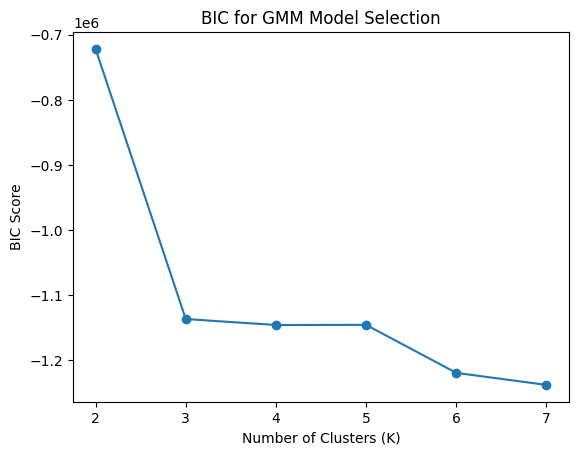

In [16]:
# Plotting the BIC scores vs a range of cluster numbers and finalising the optimum number of clusters based on the lowest BIC score:

plt.plot(k_range, bic_scores, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("BIC Score")
plt.title("BIC for GMM Model Selection")
plt.show()

In [17]:
optimal_k = k_range[np.argmin(bic_scores)]

gmm_final = GaussianMixture(
    n_components=optimal_k,
    covariance_type="full",
    random_state=42
)

# Assigning the cluster labels to the final_df:

cluster_labels = gmm_final.fit_predict(X_processed)
print(optimal_k)
final_df["cluster"] = cluster_labels
final_df["cluster"] = final_df["cluster"] + 1


7


In [18]:
final_df.head()

,user_id,avg_items_per_order,active_months,monetary_per_active_month,frequency_per_active_month,inter_purchase_gap_mean,inter_purchase_gap_std,cluster
0,1,1.0,1,25.000000,1.0,0.0,0.0,3
1,7,2.0,1,38.000000,1.0,0.0,0.0,4
2,12,1.0,1,55.299999,1.0,0.0,0.0,3
3,13,1.0,1,52.250000,1.0,0.0,0.0,3
4,15,1.0,1,52.000000,1.0,0.0,0.0,3


#### CLUSTER PROFILING (STUDYING THE CLUSTERS TO UNDERSTAND THE CUSTOMER BEHAVIOR IN EACH CLUSTER)

In [19]:
# Finding the percentage of customers each cluster has

final_df["cluster"].value_counts(normalize=True)*100

cluster
3    41.178272
4    26.402021
5    20.518317
1     5.290357
7     5.041534
6     1.282395
2     0.287103
Name: proportion, dtype: float64

In [20]:
# The clusters 3,4, and 5 has the largest number of customers. Rest of the clusters are smaller in size.

##### Grouping the clusters by total monetary_per_active_month to find out which group of customers contribute mostly to the revenue of the company:

In [21]:
# Finding the total monetary_per_active_month contributed by each cluster
cluster_revenue = (final_df.groupby("cluster")["monetary_per_active_month"].sum())

# Finding the percentage od revenue contributed by each clusters:
cluster_revenue_share = (cluster_revenue / cluster_revenue.sum())*100

print("Cluster_revenue:")
print(cluster_revenue.reset_index().sort_values(by = "monetary_per_active_month", ascending = False))
print()
print("Cluster_revenue_share")
cluster_revenue_share_df = cluster_revenue_share.reset_index().sort_values(by = "monetary_per_active_month", ascending = False).rename(columns = {"monetary_per_active_month": "percentage_revenue_contribution"})
print(cluster_revenue_share_df)

Cluster_revenue:
   cluster  monetary_per_active_month
3        4               1.034028e+06
4        5               6.365436e+05
2        3               3.168345e+05
0        1               1.616118e+05
6        7               7.638711e+04
5        6               3.433985e+04
1        2               8.842810e+03

Cluster_revenue_share
   cluster  percentage_revenue_contribution
3        4                        45.580256
4        5                        28.059024
2        3                        13.966155
0        1                         7.123894
6        7                         3.367166
5        6                         1.513710
1        2                         0.389794


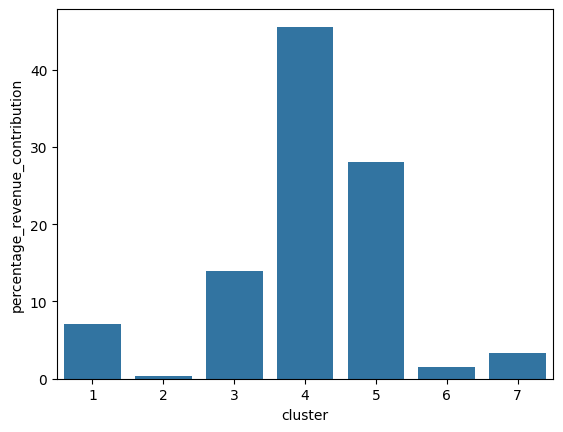

In [22]:
sns.barplot(y = "percentage_revenue_contribution", x = "cluster", data = cluster_revenue_share_df)
plt.show()

##### Insights from the above graph:
##### The group of customers in the clusters 3, 4, and 5 contribute mostly to the total revenue of the company, i.e., 45.58 + 28.059 + 13.966 ~ 87%. These three clusters of customers contribute to 87% of the total revenue of the company.
##### We have to further investigate the behavior of the customers in the clusters to find more insights and give the best business recommendations.

In [23]:
cluster_profile = (
    final_df
    .groupby("cluster")
    .agg(
        customers=("user_id", "count"),
        monetary_pm_mean=("monetary_per_active_month", "mean"),
        monetary_pm_sum = ("monetary_per_active_month", "sum"),
        freq_pm=("frequency_per_active_month", "mean"),
        items_per_order=("avg_items_per_order", "mean"),
        active_months=("active_months", "mean"),
        gap_mean=("inter_purchase_gap_mean", "mean"),
        gap_std=("inter_purchase_gap_std", "mean")
    )
    .reset_index()
)
cluster_profile

,cluster,customers,monetary_pm_mean,monetary_pm_sum,freq_pm,items_per_order,active_months,gap_mean,gap_std
0,1,1382,116.940510,1.616118e+05,1.000362,1.904004,2.000000,454.955137,0.000000
1,2,75,117.904134,8.842810e+03,2.000000,1.000000,1.000000,10.093333,0.000000
2,3,10757,29.453797,3.168345e+05,1.000093,1.000000,1.000000,0.000000,0.000000
3,4,6897,149.924331,1.034028e+06,1.010004,2.496448,1.000000,0.086269,0.000000
4,5,5360,118.758132,6.365436e+05,1.000746,1.000000,1.000000,0.000000,0.000000
5,6,335,102.507015,3.433985e+04,1.063184,1.510945,2.943284,335.774627,230.544497
6,7,1317,58.000843,7.638711e+04,1.000000,1.000000,2.000000,452.943812,0.000000


In [24]:
# Earlier we found out that most of the total revenue of company comes from the clusters 3, 4, and 5. So, sorting the cluster_profile
# in the descending order of monetary_pm_sum.

cluster_profile.sort_values(by = "monetary_pm_sum", ascending = False)

,cluster,customers,monetary_pm_mean,monetary_pm_sum,freq_pm,items_per_order,active_months,gap_mean,gap_std
3,4,6897,149.924331,1.034028e+06,1.010004,2.496448,1.000000,0.086269,0.000000
4,5,5360,118.758132,6.365436e+05,1.000746,1.000000,1.000000,0.000000,0.000000
2,3,10757,29.453797,3.168345e+05,1.000093,1.000000,1.000000,0.000000,0.000000
0,1,1382,116.940510,1.616118e+05,1.000362,1.904004,2.000000,454.955137,0.000000
6,7,1317,58.000843,7.638711e+04,1.000000,1.000000,2.000000,452.943812,0.000000
5,6,335,102.507015,3.433985e+04,1.063184,1.510945,2.943284,335.774627,230.544497
1,2,75,117.904134,8.842810e+03,2.000000,1.000000,1.000000,10.093333,0.000000


In [25]:
# From the above dataframe, it is seen that even though the cluster 3 contributes greatly to the total revenue of the company, 
# the mean monetary_per_active_month is very small. This is because cluster 3 has a large number of customers. Each of them spend an average
# amount of 29.45 per month. Since, the number of customers is large, the total contribution of the cluster to the company's revenue is high.

#### VISUALIZING THE CLUSTERS

In [ ]:
# We need not visualize all the features of the clusters.
profile_features = [
    "monetary_pm_mean",
    "freq_pm",
    "items_per_order",
    "active_months",
    "gap_mean"
] # Selecting the features to visualize

# Normalizing the features
scaler = StandardScaler()
profile_scaled = scaler.fit_transform(cluster_profile[profile_features])

# Creating a dataframe of normalized features
profile_scaled_df = pd.DataFrame(
    profile_scaled,
    columns=profile_features
)

profile_scaled_df["cluster"] = cluster_profile["cluster"]

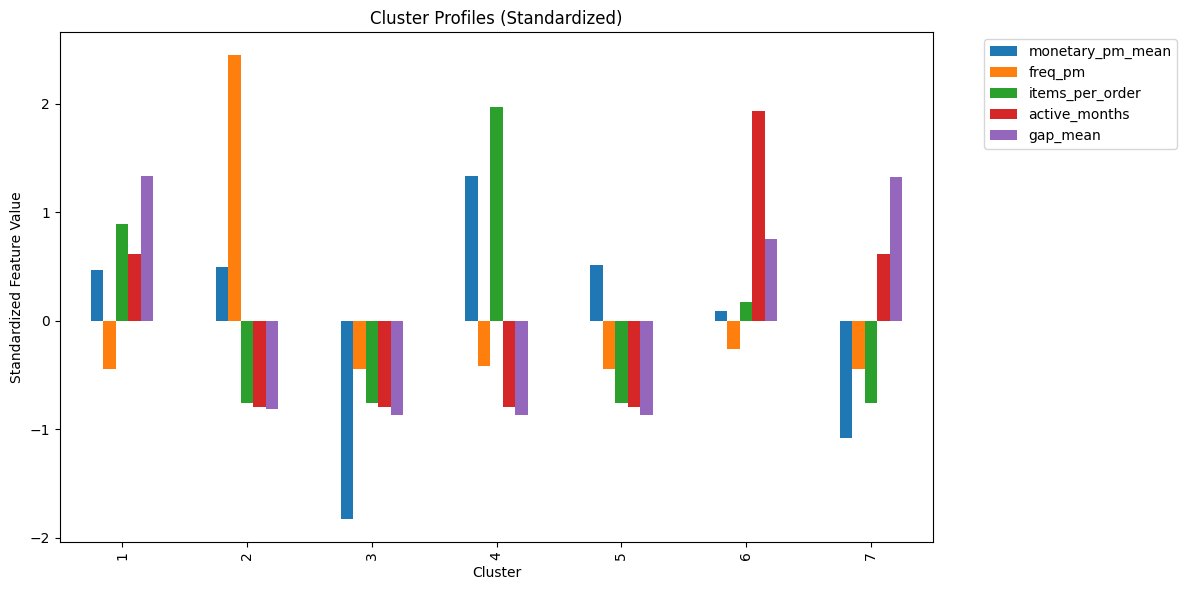

In [55]:
# Visualizing the cluster:
profile_scaled_df.set_index("cluster").plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Cluster Profiles (Standardized)")
plt.ylabel("Standardized Feature Value")
plt.xlabel("Cluster")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

# Saving the figure to the plots folder:
plt.savefig("../plots/clusters_interpretation_plot.png", dpi=300, bbox_inches="tight")
plt.show()

#### How to read the above graph:
##### The features above the average (i.e., 0) denotes high values, and those features which have negative values are low-value features.

#### ANALYSING THE BEHAVIOR OF THE CUSTOMERS FROM THE CLUSTER_PROFILE DATAFRAME AND THE PLOT:
##### 1. Cluster 4 – One-time high-value bulk buyers
##### Customers in this cluster spend the highest amount per active month and purchase the largest number of items per order (≈ 2.5 items). They have been active for only one month and have made a single purchase. This indicates that these customers made a one-time, high-value bulk purchase, but did not return afterward. Hence, they can be labeled as “One-time high-value bulk buyers.”
##### 2. Cluster 5 – One-time premium product buyers
##### Customers in this cluster spend a relatively high amount per active month, but they have been active for only one month and made a single purchase. They typically buy only one item per order, yet spend a high amount, indicating the purchase of expensive or premium products. Therefore, these customers can be labeled as “One-time premium product buyers.”
##### 3. Cluster 3 – Low-value mass customers
##### This cluster contains the largest number of customers. Each customer spends a low amount per active month and has made only one purchase within a single active month. Although individual spending is low, the large customer volume results in a significant overall revenue contribution. These customers can be labeled as “Low-value mass customers.”
##### 4. Cluster 1 – Infrequent high-value repeat customers
##### Customers in this cluster spend a good amount per active month and purchase nearly two items per order. They have been active for two months, visiting the shop approximately once per month. However, the long gap between consecutive purchases indicates infrequent buying behavior. These customers can be described as “Infrequent high-value repeat customers.”
##### 5. Cluster 7 – Low-to-mid spender dormant customers
##### Customers in this cluster spend a low amount per active month and have been active for two months, with one purchase per month. The long inter-purchase gap suggests weakening engagement or dormancy. Hence, these customers can be labeled as “Low-to-mid spender dormant customers.”
##### 6. Cluster 6 – Moderate spender, infrequent repeat customers
##### This cluster contains a small number of customers, but they spend a moderate amount per active month. They have been active for nearly three months, indicating repeat behavior. However, the large and irregular gaps between purchases suggest that they buy infrequently. These customers can be labeled as “Moderate spender, infrequent repeat customers.”
##### 7. Cluster 2 – High-value, active short-term buyers
##### This cluster has the smallest number of customers, but they spend a high amount per active month. They make multiple purchases within a single month, with a short gap (≈ 10 days) between purchases. However, their activity is limited to only one month, indicating short-lived but intense engagement. These customers can be labeled as “High-value, active short-term buyers.”

#### RECOMMENDED MARKETING STRATEGIES FOR EACH CLUSTER

#### Having understood the customer behavior of each cluster, the next step would be targeted marketing strategies to increase the revenue and customer retention.
##### Cluster 1: Infrequent high-value repeat customers: This group has a long gap in between purchases. So, the business goal would be to reduce the interpurchase gap. The steps to achieve this would involve sending remainders and seasonal or occasion-based campains.
##### Cluster 2: High-value, active short-term buyers: This group has been active for only one month. SO, the business goal would be to increase their engagement with the company. The steps to achieve this would be giving follow-up offers and loyalty enrollment, since the customer has been actively shopping for a month with just 10 days gap in between. Giving follow-up offers would get them back.
##### Cluster 3: Low-value mass customers: This group spends only very little amount per month and has been active for only one month. But since, there are a large number of customers in this cluster, the business would not risk losing them. Strategies to get them back would be giving offers, especially bundling offers, giving incentives for their second purchases, so as to encourage the customers to purchase more and sending remainder emails to increase their engagement.
##### Cluster 4: One-time, high-value bulk buyers: This group contributes the most to the total revenue of the business. The problem with this group is they purchase only one time. So, the business would aim to increase their encouragement. The business would invite them for loyalty programs, give them limited time incentives for their second purchases, personalized reorder remainders.
##### Cluster 5: One-time premium product buyers: This group has purchased expensive products for a single time. The products may be mobile phone, laptops, washing machines, etc. Since the customer purchases only once, the goal would be to increase the number of purchases. This may include giving accessory recommendations like mobile phone case, charger, etc. The company may also send warranty or service remainders.
##### Cluster 6: Moderate spender, infrequent repeat customers: The main problem here is huge gap between purchases. The business goal would be to reduce the gap between purchases. This may be achieved by sending remainders and product recommendations.
##### Cluster 7: Low-to-mid spender dormant clusters: The problem with this group is huge gap between purchases. The goal would be to reduce the gap and the risk of churn. This may be achieved by giving limited time offers or discounts, sending remainder messages like "we miss you". Giving offers may promote the customers to purchase more.

##### As we have seen earlier, the custers 3, 4, and 5 (low-value mass customers, one-time, high-value bulk buyers, and one-time premium product buyers) themselves contribute to approximately 87% of the total revenue of the business/company. So targeting these groups themselves would increase the revenue.

In [27]:
# Mapping the clusters with their respective cluster label names in final_df:

final_df["cluster"] = final_df["cluster"].map({1: "Infrequent, high-value, repeatcustomers", 2: "High-value, active short-term buyers", 
                                               3: "Low-value mass customers", 4: "One-time, high-value bulk buyers", 5: "One-time, premium product buyers",
                                               6: "Moderate spender, infrequent repeat customers", 7: "Low-to-mid spender dormant customers"})

In [28]:
final_df.head()

,user_id,avg_items_per_order,active_months,monetary_per_active_month,frequency_per_active_month,inter_purchase_gap_mean,inter_purchase_gap_std,cluster
0,1,1.0,1,25.000000,1.0,0.0,0.0,Low-value mass customers
1,7,2.0,1,38.000000,1.0,0.0,0.0,"One-time, high-value bulk buyers"
2,12,1.0,1,55.299999,1.0,0.0,0.0,Low-value mass customers
3,13,1.0,1,52.250000,1.0,0.0,0.0,Low-value mass customers
4,15,1.0,1,52.000000,1.0,0.0,0.0,Low-value mass customers


In [29]:
# Importing the rfm_df dataset and assigning the clusters to it:

rfm_df = pd.read_csv("../data/processed/rfm_features.csv")
rfm_df.head()

,user_id,monetary,frequency,last_purchase_date,recency,avg_items_per_order,average_order_value,first_purchase_date,last_purchase,customer_lifespan_days,active_months,monetary_per_active_month,frequency_per_active_month,inter_purchase_gap_mean,inter_purchase_gap_std
0,1,25.000000,1,2022-06-21 11:29:28+00:00,1290,1.0,25.000000,2022-06-21 11:29:28+00:00,2022-06-21 11:29:28+00:00,1,1,25.000000,1.0,0.0,0.0
1,7,38.000000,1,2025-05-28 07:13:09+00:00,218,2.0,38.000000,2025-05-28 07:13:09+00:00,2025-05-28 07:13:09+00:00,1,1,38.000000,1.0,0.0,0.0
2,12,55.299999,1,2021-04-06 18:52:43+00:00,1731,1.0,55.299999,2021-04-06 18:52:43+00:00,2021-04-06 18:52:43+00:00,1,1,55.299999,1.0,0.0,0.0
3,13,52.250000,1,2024-10-01 23:38:00+00:00,457,1.0,52.250000,2024-10-01 23:38:00+00:00,2024-10-01 23:38:00+00:00,1,1,52.250000,1.0,0.0,0.0
4,15,52.000000,1,2025-08-05 00:57:54+00:00,149,1.0,52.000000,2025-08-05 00:57:54+00:00,2025-08-05 00:57:54+00:00,1,1,52.000000,1.0,0.0,0.0


In [30]:
# The columns "last_purchase_date" and "last_purchase" are the same, so we can drop one of them:

rfm_df.drop("last_purchase", axis = 1, inplace = True)

In [31]:
rfm_df.head()

,user_id,monetary,frequency,last_purchase_date,recency,avg_items_per_order,average_order_value,first_purchase_date,customer_lifespan_days,active_months,monetary_per_active_month,frequency_per_active_month,inter_purchase_gap_mean,inter_purchase_gap_std
0,1,25.000000,1,2022-06-21 11:29:28+00:00,1290,1.0,25.000000,2022-06-21 11:29:28+00:00,1,1,25.000000,1.0,0.0,0.0
1,7,38.000000,1,2025-05-28 07:13:09+00:00,218,2.0,38.000000,2025-05-28 07:13:09+00:00,1,1,38.000000,1.0,0.0,0.0
2,12,55.299999,1,2021-04-06 18:52:43+00:00,1731,1.0,55.299999,2021-04-06 18:52:43+00:00,1,1,55.299999,1.0,0.0,0.0
3,13,52.250000,1,2024-10-01 23:38:00+00:00,457,1.0,52.250000,2024-10-01 23:38:00+00:00,1,1,52.250000,1.0,0.0,0.0
4,15,52.000000,1,2025-08-05 00:57:54+00:00,149,1.0,52.000000,2025-08-05 00:57:54+00:00,1,1,52.000000,1.0,0.0,0.0


In [32]:
# Assigning the clusters:
rfm_df["cluster"] = cluster_labels
rfm_df.head()

,user_id,monetary,frequency,last_purchase_date,recency,avg_items_per_order,average_order_value,first_purchase_date,customer_lifespan_days,active_months,monetary_per_active_month,frequency_per_active_month,inter_purchase_gap_mean,inter_purchase_gap_std,cluster
0,1,25.000000,1,2022-06-21 11:29:28+00:00,1290,1.0,25.000000,2022-06-21 11:29:28+00:00,1,1,25.000000,1.0,0.0,0.0,2
1,7,38.000000,1,2025-05-28 07:13:09+00:00,218,2.0,38.000000,2025-05-28 07:13:09+00:00,1,1,38.000000,1.0,0.0,0.0,3
2,12,55.299999,1,2021-04-06 18:52:43+00:00,1731,1.0,55.299999,2021-04-06 18:52:43+00:00,1,1,55.299999,1.0,0.0,0.0,2
3,13,52.250000,1,2024-10-01 23:38:00+00:00,457,1.0,52.250000,2024-10-01 23:38:00+00:00,1,1,52.250000,1.0,0.0,0.0,2
4,15,52.000000,1,2025-08-05 00:57:54+00:00,149,1.0,52.000000,2025-08-05 00:57:54+00:00,1,1,52.000000,1.0,0.0,0.0,2


#### ESTIMATED BUSINESS IMPACT OF CLUSTER-BASED MARKETING STRATEGIES
##### Having understood the customer behavior in each cluster and suggested the targetted marketing actions, we now estimate the business impact by assuming that we applied the marketing strategies to the clusters.
##### It was discovered earlier that the clusters 3, 4, and 5 contribute to 97% of the total revenue of the company. So, we primarily focus on these three clusters.
##### Cluster 3: Low-value mass customers (the largest cluster): These customers spend a very low amount of money and they are one-time purchasers, so the business goal is to increase the frequency of their purchases. Since these customers are large in number, increasing the purchase frequency would increase the revenue. Now, assuming that we applied the targeted market strategies to the cluster, which drove 5% of the total customers in the cluster to make a second purchase spending the same amount of money as the first purchase, we can estimate the revenue increase percentage.

In [33]:
# From the cluster_profile table, filtering the details of cluster 3:

c3 = cluster_profile[cluster_profile["cluster"] == 3].iloc[0]
c3

cluster                  3.000000
customers            10757.000000
monetary_pm_mean        29.453797
monetary_pm_sum     316834.491928
freq_pm                  1.000093
items_per_order          1.000000
active_months            1.000000
gap_mean                 0.000000
gap_std                  0.000000
Name: 2, dtype: float64

In [34]:
# Now assuming that after the targeted marketing strategies, 5% of the customers made a second purchase, and estimating the increase in revenue due to
# that:

delta_r3 = 0.05*c3["customers"] * c3["monetary_pm_mean"]
delta_r3

np.float64(15841.72459639311)

In [35]:
# Here, delta_r3 represents an increase in revenue due to the assumption. So, even if 5% of the customers make a second purchase can drive the revenue
# to increase by 15841 units.

##### Cluster 4: One-time, high value bulk buyers: In this cluster, the customers make only one purchase. So the goal here is also to make them make more purchases. Now, making a conservative assumption that 5% of the customers make a second purchase after the tageting market actions and estimating the reveue increase:

In [36]:
# Filtering cluster 4 from the cluster_profile:

c4 = cluster_profile[cluster_profile["cluster"] == 4].iloc[0]
c4

cluster             4.000000e+00
customers           6.897000e+03
monetary_pm_mean    1.499243e+02
monetary_pm_sum     1.034028e+06
freq_pm             1.010004e+00
items_per_order     2.496448e+00
active_months       1.000000e+00
gap_mean            8.626939e-02
gap_std             0.000000e+00
Name: 3, dtype: float64

In [37]:
# Estimating the revenue increase based on the assumption:
delta_r4 = 0.05 * c4["customers"] * c4["monetary_pm_mean"]
delta_r4

np.float64(51701.40553894043)

##### Cluster 5: One-time premium product buyers: Here, the goal is to increase the basket size by recommending accessories. Here, the conservative assumption is 30% of the customers purchases one extra item per order after the targetted marketing actions. To find the impact of this assumption, we have to calculate the average order value (AOV), i.e.,the amount spent by a customer per order and the price per item:

In [38]:
# Filtering the details of cluster 5 from the cluster_profile table:

c5 = cluster_profile[cluster_profile["cluster"] == 5].iloc[0]
c5

cluster                  5.000000
customers             5360.000000
monetary_pm_mean       118.758132
monetary_pm_sum     636543.588976
freq_pm                  1.000746
items_per_order          1.000000
active_months            1.000000
gap_mean                 0.000000
gap_std                  0.000000
Name: 4, dtype: float64

In [39]:
# Average order value of the customers in cluster 5 is calculated by dividing the monetary_pm_mean and frequency_pm:

AOV = c5["monetary_pm_mean"]/c5["freq_pm"]

# The price_per_item is calculated by dividing the AOV and the items_per_order:
price_per_item = AOV/c5["items_per_order"]

In [40]:
# Estimating the increase in revenue based on the assumption

delta_r5 = 0.03 * 1 * c5["customers"] * price_per_item
delta_r5

np.float64(19082.067320530525)

In [41]:
# Now calculating the total increase in revenue after the assumed impact and the baseline_revenue (that is, the total revenue of the company before the
# targeted actions):
total_revenue_increase = delta_r3 + delta_r4 + delta_r5

# Baseline revenue:
baseline_revenue = cluster_profile["monetary_pm_sum"].sum()
print(f"The total revenue increase is {total_revenue_increase}.")
print(f"The total revenue of the company before the assumptions of targeted marketing actions is {baseline_revenue}.")

The total revenue increase is 86625.19745586406.
The total revenue of the company before the assumptions of targeted marketing actions is 2268587.7470104694.


In [42]:
# Now calculating the percentage of the total revenue increase after the assumptions of the targeted marketing actions:

percentage_revenue_increase = (total_revenue_increase/baseline_revenue)*100
print(f"The estimated revenue increase based on the assumptions is {percentage_revenue_increase} %.")

The estimated revenue increase based on the assumptions is 3.8184636045054106 %.


##### So, based on the assumptions, if the targeted marketing strategies were applied, the company may able to increase the revenue by approximately 3.8 %.

##### VISUALIZING THE ESTIMATED IMPACT OF TARGETED ACTIONS ON EACH CLUSTER

In [43]:
# Computing the baseline revenue contributed by each cluster before the eatimated impact of the assumed targeted actions:

R3 = c3["monetary_pm_sum"]
R4 = c4["monetary_pm_sum"]
R5 = c5["monetary_pm_sum"]

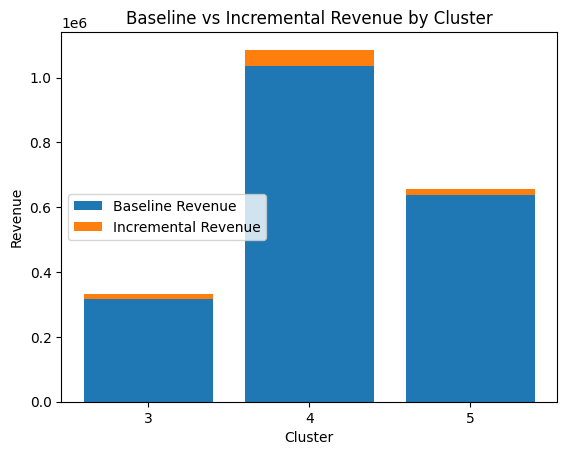

In [54]:
# Plotting the graph

clusters = ['3', '4', '5'] # Cluster numbers
baseline = [R3, R4, R5]
incremental = [delta_r3, delta_r4, delta_r5]

plt.bar(clusters, baseline, label="Baseline Revenue")
plt.bar(clusters, incremental, bottom=baseline, label="Incremental Revenue")

plt.xlabel("Cluster")
plt.ylabel("Revenue")
plt.title("Baseline vs Incremental Revenue by Cluster")
plt.legend()

# Saving the plot
plt.savefig("../plots/estimated_impact_plot", dpi = 300, bbox_inches = "tight")

plt.show()

##### From the above graph, it is seen that the incremental revenue raises the total revenue in each cluster. This is the estimated impact generated by assuming that the business applied the targeted marketing strategies.

#### KEY BUSINESS TAKEAWAYS AND RECOMMENDATIONS
##### Clusters 3, 4, and 5 contribute approximately 87% of total revenue and should be prioritized for targeted interventions.
##### Cluster-based strategies could conservatively increase overall revenue by ~3.8 %, under scenario-based assumptions.
##### The highest estimated ROI comes from converting one-time high-value buyers into repeat customers.
##### Basket expansion among premium buyers provides incremental revenue uplift without relying on long-term retention assumptions.
##### All impact estimates are counterfactual, scenario-based, and assume no increase in customer acquisition costs.

#### ASSUMPTIONS AND LIMITATIONS
##### Impact estimates assume partial customer adoption and no change in acquisition costs.
##### Revenue uplift is estimated under counterfactual scenarios and does not imply causality.
##### Customer lifetime value and churn labels were not available.
##### Seasonal effects and marketing costs were not included.